<a href="https://colab.research.google.com/github/nobishun/bridge-risk-analysis/blob/main/notebooks/04_integrated_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. 統合評価 - 補修補強対策の優先順位付け

## このノートブックの目的
「交通量×迂回路長」の4分類マトリクスと、クラスター分析（6分類）の結果を統合し、橋梁の補修補強対策の優先順位を決定します。

## 入力
- `../data/processed/03_bridges_clustered.gpkg`（`03_eda_clustering.ipynb` の出力）

## 出力
- `../data/processed/final_analysis_gdf.gpkg` / `.csv`
  ダッシュボード（Streamlitアプリ）が読み込む、最終的な分析結果データ（迂回路の経路ジオメトリ`detour_route_wkt`を含み、地図上での迂回路表示に利用します）


## 0. 環境準備・データ読み込み

In [ ]:
import os

import geopandas as gpd
!pip install japanize_matplotlib
import japanize_matplotlib  # 日本語表示のために必要
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#gdf = gpd.read_file("../data/processed/03_bridges_clustered.gpkg")
gdf = gpd.read_file("/content/03_bridges_clustered.gpkg")
# cluster_6_labelは整数のカテゴリ値のため、hueで色分けする際に連続値として
# 扱われてしまわないよう、可視化用に文字列型の列も用意しておく
gdf["cluster_6_label_str"] = gdf["cluster_6_label"].astype(int).astype(str)
print(f"読み込んだ橋梁数: {len(gdf)}")
gdf.head()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 24.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=cee6aac4d863960669c38f911bb1f03cbabf326d88399de745becee3d685c11a
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
読み込んだ橋梁数: 1226


,dpf_index,bridge_name,osm_u,osm_v,osm_key,distance_m,dpf_title,dpf_lat,dpf_lon,dpf_gyousei_kuiki_shikuchouson_mei,...,index_right,voronoi_title,traffic_count_24h_auto,detour_length_m,detour_path_nodes,detour_route_wkt,osm_highway_aggregated,cluster_6_label,geometry,cluster_6_label_str
0,2,玉野橋,617126346,617125876,0,0.36,玉野橋,35.60737,139.64151,世田谷区,...,1424,交通調査基本区間番号:13304660040 (一般国道４６６号（第三京浜道路）),64469.0,597.130646,"[617126346, 269668898, 281381332, 2895717415, ...","LINESTRING (139.6413898 35.6068357, 139.641520...",5,0,POINT (-17379.096 -43543.111),0
1,3,矢澤橋,537929170,537929320,0,4.80,矢澤橋,35.61337,139.64220,世田谷区,...,1389,交通調査基本区間番号:13304660020 (一般国道４６６号),48526.0,123.020137,"[537929170, 537929165, 537929267, 537929320]","LINESTRING (139.6422151 35.6133798, 139.642212...",5,4,POINT (-17315.289 -42877.587),4
2,4,無名五十七号橋,811135988,1033248469,0,4.09,無名五十七号橋,35.65581,139.63255,世田谷区,...,1386,交通調査基本区間番号:13601180090 (調布経堂停車場線),10873.0,173.074616,"[811135988, 811135982, 811129543, 1033248469]","LINESTRING (139.6324484 35.6560883, 139.631962...",5,4,POINT (-18179.897 -38167.495),4
3,5,中ノ橋,563748534,822683230,0,23.75,中ノ橋,35.69250,139.67889,中野区,...,1620,交通調査基本区間番号:13403170230 (環状六号線),34486.0,162.609045,"[563748534, 670401581, 563748916, 563748907, 5...","LINESTRING (139.6788671 35.6924568, 139.678954...",4,3,POINT (-13977.646 -34104.614),3
4,7,大井北部陸橋(ランプ部２),582140959,7093114606,0,40.83,大井北部陸橋(ランプ部２),35.59491,139.75565,品川区,...,2325,交通調査基本区間番号:13303570250 (一般国道３５７号),47937.0,78.130461,"[582140959, 13439528430, 7104540462, 134395284...","LINESTRING (139.7557748 35.5952666, 139.755574...",3,2,POINT (-7039.158 -44939.591),2


## 1. 交通量×迂回路長の4分類マトリクス

交通量（`traffic_count_24h_auto`）と迂回路長（`detour_length_m`）を、それぞれの中央値を基準に「多い／少ない」「長い／短い」に分け、4つの象限に分類します。「交通量が多く、迂回路も長い（右上）」ほど、通行止め時の社会的影響が大きいと考えられます。


In [ ]:
median_traffic = gdf["traffic_count_24h_auto"].median()
median_detour = gdf["detour_length_m"].median()


def categorize_quadrant(row):
    is_high_traffic = row["traffic_count_24h_auto"] >= median_traffic
    is_long_detour = row["detour_length_m"] >= median_detour
    if is_high_traffic and is_long_detour:
        return 4  # 右上：交通量多 x 迂回路長
    elif is_high_traffic:
        return 3  # 右下：交通量多 x 迂回路短
    elif is_long_detour:
        return 2  # 左上：交通量少 x 迂回路長
    return 1  # 左下：交通量少 x 迂回路短


gdf["traffic_detour_quadrant"] = gdf.apply(categorize_quadrant, axis=1)
gdf["traffic_detour_quadrant"].value_counts().sort_index()


,count
traffic_detour_quadrant,
1,254
2,352
3,298
4,322


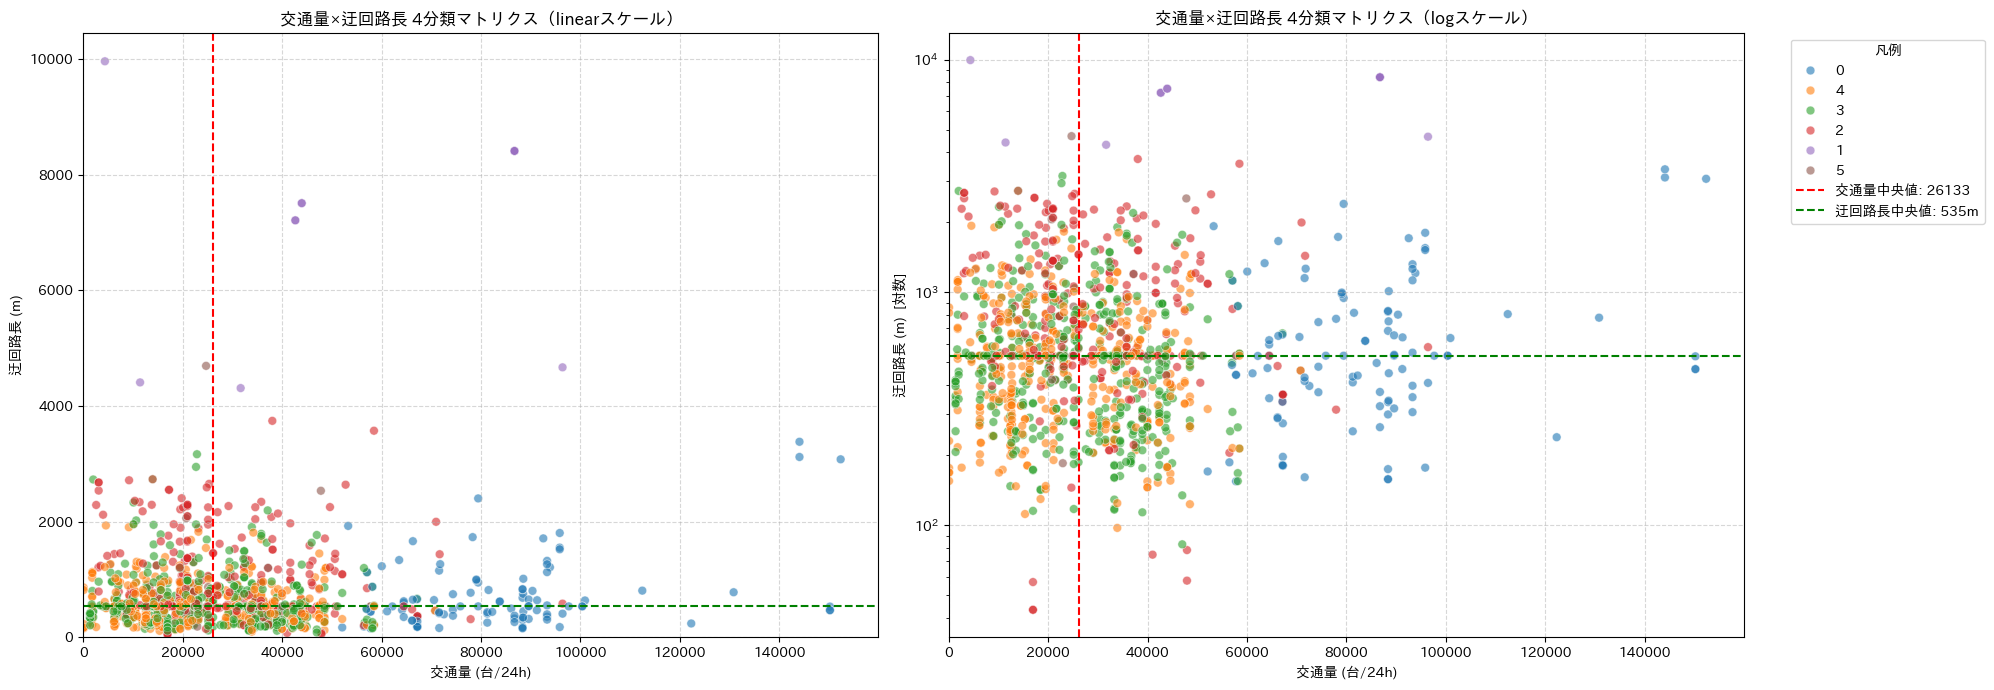

In [ ]:
def plot_quadrant_scatter(gdf, yscale="linear", ax=None):
    """交通量×迂回路長の散布図に、中央値を基準にした4象限のラベルを描画する。"""
    ax = ax or plt.gca()
    sns.scatterplot(
        data=gdf, x="traffic_count_24h_auto", y="detour_length_m",
        hue="cluster_6_label_str", palette="tab10", alpha=0.6, edgecolor="w", s=40, ax=ax,
    )
    ax.axvline(median_traffic, color="red", linestyle="--", label=f"交通量中央値: {median_traffic:.0f}")
    ax.axhline(median_detour, color="green", linestyle="--", label=f"迂回路長中央値: {median_detour:.0f}m")
    ax.set_xlim(left=0)
    if yscale == "log":
        ax.set_yscale("log")
    else:
        ax.set_ylim(bottom=0)
    ax.set_xlabel("交通量 (台/24h)")
    ax.set_ylabel(f"迂回路長 (m){'  [対数]' if yscale == 'log' else ''}")
    ax.set_title(f"交通量×迂回路長 4分類マトリクス（{yscale}スケール）")
    ax.grid(True, linestyle="--", alpha=0.5)
    return ax


fig, axes = plt.subplots(1, 2, figsize=(20, 7))
plot_quadrant_scatter(gdf, yscale="linear", ax=axes[0])
plot_quadrant_scatter(gdf, yscale="log", ax=axes[1])
axes[0].get_legend().remove()
axes[1].legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="凡例")
plt.tight_layout()
plt.show()


## 2. マトリクス×クラスター（6分類）の統合

In [ ]:
QUADRANT_NAMES = {
    1: "左下: 交通量少 x 迂回路短",
    2: "左上: 交通量少 x 迂回路長",
    3: "右下: 交通量多 x 迂回路短",
    4: "右上: 交通量多 x 迂回路長",
}

counts_table = pd.crosstab(gdf["traffic_detour_quadrant"], gdf["cluster_6_label"]).rename(index=QUADRANT_NAMES)
counts_table


cluster_6_label,0,1,2,3,4,5
traffic_detour_quadrant,,,,,,
左下: 交通量少 x 迂回路短,0,0,19,103,130,2
左上: 交通量少 x 迂回路長,0,2,111,120,109,10
右下: 交通量多 x 迂回路短,51,0,32,127,83,5
右上: 交通量多 x 迂回路長,54,9,94,86,74,5


一見リスクが低そうに見える「左下（交通量少×迂回路短）」の中にも、老朽化が進行したクラスター5（戦前生まれの高齢橋）が一定数含まれていることが分かります。これらは交通への影響は小さいものの、構造物としての老朽化リスクは別枠で考慮する必要があります。


## 3. 優先順位スコアの設計

**検討過程・スコアリングの根拠**

- **4象限の優先度**（`03`のクラスター解釈を踏まえ、右上ほど社会的影響が大きいと判断）：右上(4)＞右下(3)＞左上(2)＞左下(1)
- **クラスターの優先度**（`03`のクラスター解釈まとめより）：クラスター1(交通集中×長距離迂回)＞4(高交通需要)＞5(老朽化進行)＞2(超長大橋)＞3(標準橋群・幹線)＞0(標準橋群)
- **統合スコア**：象限の影響度をより重視するため、`quadrant_priority_score × 2 + cluster_priority_score` とし、**値が小さいほど優先度が高い**ものとします。同点の場合は交通量、迂回路長の降順で順位を決定します。


In [ ]:
QUADRANT_PRIORITY = {4: 1, 3: 2, 2: 3, 1: 4}
CLUSTER_PRIORITY = {1: 1, 4: 2, 5: 3, 2: 4, 3: 5, 0: 6}

gdf["quadrant_priority_score"] = gdf["traffic_detour_quadrant"].map(QUADRANT_PRIORITY)
gdf["cluster_priority_score"] = gdf["cluster_6_label"].astype(int).map(CLUSTER_PRIORITY)
gdf["combined_priority_score"] = gdf["quadrant_priority_score"] * 2 + gdf["cluster_priority_score"]

ranked = gdf.sort_values(
    by=["combined_priority_score", "traffic_count_24h_auto", "detour_length_m"],
    ascending=[True, False, False],
).reset_index(drop=True)
ranked["overall_rank"] = ranked.index + 1

gdf = gdf.merge(ranked[["dpf_index", "overall_rank"]], on="dpf_index", how="left")

## 4. 総合優先度ランキング

In [ ]:
top_30 = ranked.head(30)
top_30[[
    "bridge_name", "traffic_count_24h_auto", "detour_length_m",
    "cluster_6_label", "combined_priority_score", "overall_rank",
]]


,bridge_name,traffic_count_24h_auto,detour_length_m,cluster_6_label,combined_priority_score,overall_rank
0,神田橋,96405.0,4668.146222,1,3,1
1,椎名橋,86739.0,8409.620619,1,3,2
2,仮-西池-A1～仮-西池-A2,86739.0,8409.620619,1,3,3
3,大和田橋,86739.0,8409.620619,1,3,4
4,新板橋（下り）,43961.0,7506.839856,1,3,5
5,新板橋（上り）,43961.0,7506.839856,1,3,6
6,大井北２号橋,42668.0,7210.071505,1,3,7
7,中環-0005（大-0006）（跨ぐ）,42668.0,7210.071505,1,3,8
8,芝園橋,31677.0,4309.136435,1,3,9
9,弁天橋,58485.0,545.974424,4,4,10


In [ ]:
print("上位30橋のクラスター分布:")
top_30["cluster_6_label"].value_counts().sort_index()


上位30橋のクラスター分布:


,count
cluster_6_label,
1,9
4,21


## 5. 最終データセットの保存

ダッシュボード（Streamlitアプリ）で使う想定のため、必要な列に絞って保存します。


In [ ]:
output_dir = "../data/processed"
os.makedirs(output_dir, exist_ok=True)

FINAL_COLUMNS = [
    "dpf_index", "bridge_name", "dpf_kasetsu_nendo", "dpf_fukuin", "dpf_kyouchou",
    "osm_highway", "osm_highway_aggregated", "osm_oneway",
    "traffic_count_24h_auto", "detour_length_m",
    "cluster_6_label", "traffic_detour_quadrant",
    "combined_priority_score", "overall_rank",
    "detour_route_wkt",  # ダッシュボードでの迂回路表示(オン/オフ)用の経路ジオメトリ
    "geometry",
]
final_gdf = gdf[FINAL_COLUMNS].copy()

final_gdf.to_file(os.path.join(output_dir, "final_analysis_gdf.gpkg"), driver="GPKG")
final_gdf.drop(columns="geometry").to_csv(os.path.join(output_dir, "final_analysis_gdf.csv"), index=False)
print(f"saved: final_analysis_gdf.gpkg / .csv ({len(final_gdf)} rows)")

saved: final_analysis_gdf.gpkg / .csv (1226 rows)


## まとめ・今後の展開

**本分析の意義**
国土交通DPF（行政管理データ）とOpenStreetMap（オープン地理空間データ）を組み合わせることで、架設年度や規模といった橋単体（点）の評価に加えて、「通行止めになった場合の迂回距離」という、地域社会への影響度（面）を考慮した優先順位付けを行いました。

**今後の課題**
行政データ（DPF）とボランティア主体のOSMとでは、道路の結線状態や属性情報に一部不整合が生じるリスクがあり、分析前のデータクリーニングが引き続き重要です。また現在の迂回路計算は幾何学的な最短距離ベースであり、時間帯交通規制や渋滞状況までは反映されていません。